In [2]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path
import dask.dataframe as dd
import cmocean
import xesmf as xe
import seaborn as sns
import geopandas as gpd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rioxarray as rio
import seaborn as sns
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import dask.array as da
from dask.diagnostics import ProgressBar
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
from dask.distributed import Client
from google.cloud import storage
from numba import njit, prange
from scipy import ndimage

try:
    import flox
except ImportError:
    print("[ACTEA_downscale] Warning: flox not installed - continuing without")

import sys
sys.path.append('../')
import ACTEA_gcs
import ACTEA_merge_datasets

# Settings for the script
sns.set_style("white")
actea_variables = ["uo","vo"]
time = "2018-01-01"
coarsen_step = 1
lat_lon_ext = [360-173., 360-152., 54., 68.]
depth = 5.0
frequency = "monthly"
base_path = "glorys_validation"
verbose = True

gcs = ACTEA_gcs.ACTEA_gcs(frequency)
gcs.setup_actea_google_storage()
if not Path(base_path).exists():
    Path(base_path).mkdir(parents=True)

INT_DAYS = 15
# Physical parameters for 7-day integration with m/s velocities
DT_HOURS = 1.0  # 1-hour timestep


### Load the Ba+SD downscaled GLORYS data
Load the final dataset after downscaling the coarsened GLORYS dataset.

In [3]:
def load_actea_datasets():
    ds_all_actea = {}
    for varname, iterations in zip(actea_variables, [0, 0]):
        ds_all_actea[varname], ds_plotfile = ACTEA_merge_datasets.create_merged_ds(["test_glorys"],
                                                                "GLORYS12V1",
                                                                "surface",
                                                            varname, 
                                                            "ssp585", 
                                                            "r1i1p1f1", 
                                                            depth,
                                                            iterations=iterations,
                                                            frequency=frequency)
    print(f"ACTEA: {varname} dataset size in MB", ds_all_actea[varname][varname].size / (1024*1024))
    
    ds_uo_actea = (ds_all_actea["uo"].assign_coords(lon=(np.mod(ds_all_actea["uo"].lon, 360)))).sortby("lon")
    ds_vo_actea = (ds_all_actea["vo"].assign_coords(lon=(np.mod(ds_all_actea["vo"].lon, 360)))).sortby("lon")

    ds_uo_actea = ds_uo_actea.sel(lon=slice(lat_lon_ext[0], lat_lon_ext[1]), lat=slice(lat_lon_ext[2], lat_lon_ext[3]))
    ds_vo_actea = ds_vo_actea.sel(lon=slice(lat_lon_ext[0], lat_lon_ext[1]), lat=slice(lat_lon_ext[2], lat_lon_ext[3]))
    return ds_uo_actea, ds_vo_actea

### Load the original GLORYS dataset
This dataset is stored from 1993 to 2019. The dataset is stored in the form of a netCDF file. The dataset
is generated and upload to GCS automatically when you run the downscaling using ´GLORYS12V1´ as the model. This dataset is
then coarsened and used as the input for the downscaling process. 

In [4]:
def load_glorys_datasets():
    ds_uo = gcs.open_dataset_on_gs(f"downscaling/test_glorys/ssp585/GLORYS12V1/uo/GLORYS12V1_r1i1p1f1_uo_surface_{depth}m_GLORYS12V1_full.nc", engine="h5netcdf")
    ds_vo = gcs.open_dataset_on_gs(f"downscaling/test_glorys/ssp585/GLORYS12V1/vo/GLORYS12V1_r1i1p1f1_vo_surface_{depth}m_GLORYS12V1_full.nc", engine="h5netcdf")
    ds_uo = (ds_uo.assign_coords(lon=(np.mod(ds_uo.lon, 360)))).sortby("lon").sel(lon=slice(lat_lon_ext[0], lat_lon_ext[1]), lat=slice(lat_lon_ext[2], lat_lon_ext[3]))
    ds_vo = (ds_vo.assign_coords(lon=(np.mod(ds_vo.lon, 360)))).sortby("lon").sel(lon=slice(lat_lon_ext[0], lat_lon_ext[1]), lat=slice(lat_lon_ext[2], lat_lon_ext[3]))

    return ds_uo, ds_vo

ds_uo_glorys, ds_vo_glorys = load_glorys_datasets()

print("GLORYS12V1 fine uo size in MB", ds_uo_glorys.uo.size / (1024*1024))
print("GLORYS12V1 fine vo size in MB", ds_vo_glorys.vo.size / (1024*1024))
print(f"Time range: {ds_uo_glorys.time.min().values} to {ds_uo_glorys.time.max().values}")


GLORYS12V1 fine uo size in MB 11.958240509033203
GLORYS12V1 fine vo size in MB 11.958240509033203
Time range: 1993-01-16T12:00:00.000000000 to 2019-12-16T12:00:00.000000000


[ACTEA_merge_datasets] ssp585 uo (324, 217, 337)
[ACTEA_merge_datasets] ssp585 vo (324, 217, 337)
ACTEA: vo dataset size in MB 22.59616470336914
Running corrected LCS analysis forward for 2015 to 2019...
Integration: 15 days, 1.0 hour timestep, 360 steps
Calculating multi-year average FTLE...
Processing year 2015...
Extracting data for year: 2015
Calculating FTLE for month 1...
Calculating FTLE for month 2...
Calculating FTLE for month 3...
Calculating FTLE for month 4...
Calculating FTLE for month 5...
Calculating FTLE for month 6...
Calculating FTLE for month 7...
Calculating FTLE for month 8...
Calculating FTLE for month 9...
Calculating FTLE for month 10...
Calculating FTLE for month 11...
Calculating FTLE for month 12...
Processing year 2016...
Extracting data for year: 2016
Calculating FTLE for month 1...
Calculating FTLE for month 2...
Calculating FTLE for month 3...
Calculating FTLE for month 4...
Calculating FTLE for month 5...
Calculating FTLE for month 6...
Calculating FTLE 

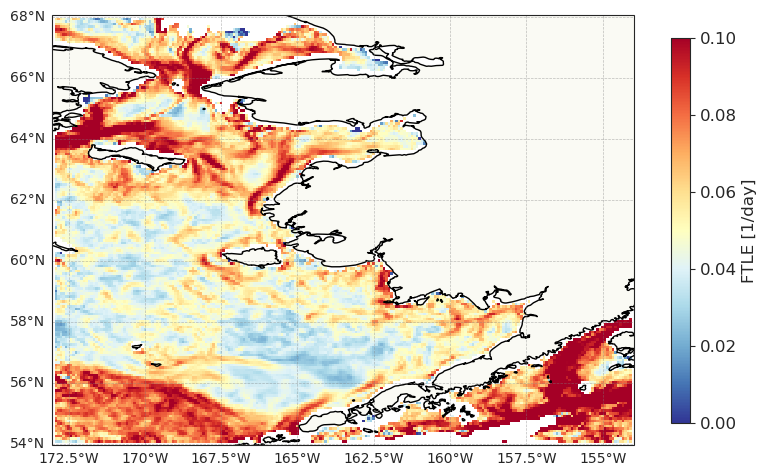

Running corrected LCS analysis forward for 2015 to 2019...
Integration: 15 days, 1.0 hour timestep, 360 steps
Calculating multi-year average FTLE...
Processing year 2015...
Extracting data for year: 2015
Calculating FTLE for month 1...
Calculating FTLE for month 2...
Calculating FTLE for month 3...
Calculating FTLE for month 4...
Calculating FTLE for month 5...
Calculating FTLE for month 6...
Calculating FTLE for month 7...
Calculating FTLE for month 8...
Calculating FTLE for month 9...
Calculating FTLE for month 10...
Calculating FTLE for month 11...
Calculating FTLE for month 12...
Processing year 2016...
Extracting data for year: 2016
Calculating FTLE for month 1...
Calculating FTLE for month 2...
Calculating FTLE for month 3...
Calculating FTLE for month 4...
Calculating FTLE for month 5...
Calculating FTLE for month 6...
Calculating FTLE for month 7...
Calculating FTLE for month 8...
Calculating FTLE for month 9...
Calculating FTLE for month 10...
Calculating FTLE for month 11...


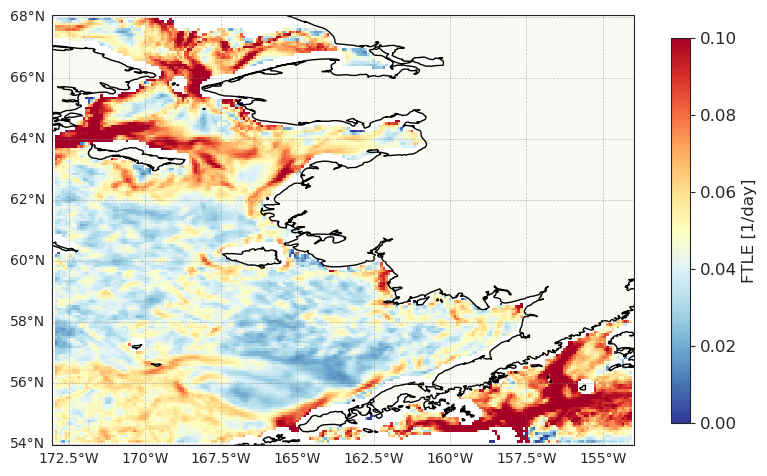

In [ ]:

@njit
def lat_lon_to_meters(lat_deg):
    """Convert lat/lon grid spacing to meters at given latitude"""
    R_earth = 6371000.0  # Earth radius in meters
    lat_rad = np.radians(lat_deg)
    
    meters_per_deg_lat = R_earth * np.pi / 180.0
    meters_per_deg_lon = R_earth * np.pi / 180.0 * np.cos(lat_rad)
    
    return meters_per_deg_lat, meters_per_deg_lon

def binary_thinning(ridges):
    """Basic binary thinning implementation"""
    structure = np.array([[0, 1, 0],
                         [1, 1, 1],
                         [0, 1, 0]], dtype=np.uint8)
    eroded = ndimage.binary_erosion(ridges, structure)
    return ridges & ~eroded

@njit
def bilinear_interp(x, y, field, lon, lat):
    """Perform bilinear interpolation with proper bounds checking"""
    # Check bounds first
    if x < lon[0] or x > lon[-1] or y < lat[0] or y > lat[-1]:
        return np.nan
    
    # Find the indices of the surrounding grid points
    i0 = np.searchsorted(lon, x) - 1
    j0 = np.searchsorted(lat, y) - 1
    
    # Handle edge cases
    i0 = max(0, min(i0, len(lon) - 2))
    j0 = max(0, min(j0, len(lat) - 2))
    i1 = i0 + 1
    j1 = j0 + 1
    
    # Check for NaN values in the field
    if (np.isnan(field[j0, i0]) or np.isnan(field[j0, i1]) or 
        np.isnan(field[j1, i0]) or np.isnan(field[j1, i1])):
        return np.nan
    
    # Calculate the weights
    wx = (x - lon[i0]) / (lon[i1] - lon[i0])
    wy = (y - lat[j0]) / (lat[j1] - lat[j0])
    
    # Perform bilinear interpolation
    value = (1 - wx) * (1 - wy) * field[j0, i0] + \
            wx * (1 - wy) * field[j0, i1] + \
            (1 - wx) * wy * field[j1, i0] + \
            wx * wy * field[j1, i1]
    
    return value

@njit
def rk4_step(x, y, u_field, v_field, lon, lat, dt):
    """Perform a single RK4 integration step with NaN checking"""
    # RK4 integration with proper error handling
    k1x = bilinear_interp(x, y, u_field, lon, lat)
    k1y = bilinear_interp(x, y, v_field, lon, lat)
    
    if np.isnan(k1x) or np.isnan(k1y):
        return np.nan, np.nan
    
    k2x = bilinear_interp(x + 0.5 * dt * k1x, y + 0.5 * dt * k1y, u_field, lon, lat)
    k2y = bilinear_interp(x + 0.5 * dt * k1x, y + 0.5 * dt * k1y, v_field, lon, lat)
    
    if np.isnan(k2x) or np.isnan(k2y):
        return np.nan, np.nan
    
    k3x = bilinear_interp(x + 0.5 * dt * k2x, y + 0.5 * dt * k2y, u_field, lon, lat)
    k3y = bilinear_interp(x + 0.5 * dt * k2x, y + 0.5 * dt * k2y, v_field, lon, lat)
    
    if np.isnan(k3x) or np.isnan(k3y):
        return np.nan, np.nan
    
    k4x = bilinear_interp(x + dt * k3x, y + dt * k3y, u_field, lon, lat)
    k4y = bilinear_interp(x + dt * k3x, y + dt * k3y, v_field, lon, lat)
    
    if np.isnan(k4x) or np.isnan(k4y):
        return np.nan, np.nan
    
    x_new = x + (dt / 6.0) * (k1x + 2 * k2x + 2 * k3x + k4x)
    y_new = y + (dt / 6.0) * (k1y + 2 * k2y + 2 * k3y + k4y)
    
    return x_new, y_new

@njit(parallel=True)
def compute_flow_map_corrected(lon, lat, u_field, v_field, integration_time_seconds, dt_seconds, steps):
    """
    Compute the flow map by integrating particles for 7 days.
    Velocities are in m/s, time in seconds.
    """
    # Initialize flow map
    flow_map = np.zeros((len(lat), len(lon), 2))
    
    # Calculate signed dt (negative for backward integration)
    dt_signed = dt_seconds * np.sign(integration_time_seconds)
    
    # Convert velocity from m/s to degrees/s for lat/lon coordinates
    # This is approximate but necessary for lat/lon grids
    lat_center = np.mean(lat)
    dy_meters_per_deg, dx_meters_per_deg = lat_lon_to_meters(lat_center)
    
    # Compute flow map for each grid point
    for j in prange(len(lat)):
        for i in range(len(lon)):
            # Initial position
            x, y = lon[i], lat[j]
            
            # Skip if the initial position is in a NaN region
            if np.isnan(u_field[j, i]) or np.isnan(v_field[j, i]):
                flow_map[j, i, 0] = np.nan
                flow_map[j, i, 1] = np.nan
                continue
            
            # Convert velocity from m/s to degrees/s at this latitude
         #   u_deg_per_s = u_field[j, i] / dx_meters_per_deg
         #   v_deg_per_s = v_field[j, i] / dy_meters_per_deg
            
            # Create temporary velocity fields in degrees/s
            u_field_deg = np.zeros_like(u_field)
            v_field_deg = np.zeros_like(v_field)
            
            for jj in range(len(lat)):
                for ii in range(len(lon)):
                    if not (np.isnan(u_field[jj, ii]) or np.isnan(v_field[jj, ii])):
                        u_field_deg[jj, ii] = u_field[jj, ii] / dx_meters_per_deg
                        v_field_deg[jj, ii] = v_field[jj, ii] / dy_meters_per_deg
                    else:
                        u_field_deg[jj, ii] = np.nan
                        v_field_deg[jj, ii] = np.nan
            
            # Integrate the particle trajectory
            integration_successful = True
            for step in range(steps):
                x_new, y_new = rk4_step(x, y, u_field_deg, v_field_deg, lon, lat, dt_signed)
                
                # Check if integration failed
                if np.isnan(x_new) or np.isnan(y_new):
                    integration_successful = False
                    break
                
                # Check if the new position is within the domain
                if (x_new < lon[0] or x_new > lon[-1] or 
                    y_new < lat[0] or y_new > lat[-1]):
                    integration_successful = False
                    break
                
                # Update position
                x, y = x_new, y_new
            
            # Store the final position in the flow map
            if integration_successful:
                flow_map[j, i, 0] = x
                flow_map[j, i, 1] = y
            else:
                flow_map[j, i, 0] = np.nan
                flow_map[j, i, 1] = np.nan
    
    return flow_map

@njit(parallel=True)
def compute_ftle_corrected(flow_map, lon, lat, integration_time_seconds):
    """
    Compute the FTLE field from the flow map with proper coordinate scaling.
    """
    # Initialize FTLE field
    ftle = np.zeros((len(lat), len(lon)))
    
    # Get coordinate scaling at center latitude
    lat_center = np.mean(lat)
    dy_meters_per_deg, dx_meters_per_deg = lat_lon_to_meters(lat_center)
    
    # Grid spacing in degrees
    dx_deg = lon[1] - lon[0]
    dy_deg = lat[1] - lat[0]
    
    # Grid spacing in meters
    dx_meters = dx_deg * dx_meters_per_deg
    dy_meters = dy_deg * dy_meters_per_deg
    
    # Compute FTLE for each interior grid point
    for j in prange(1, len(lat) - 1):
        for i in range(1, len(lon) - 1):
            # Skip if the flow map contains NaN values
            if (np.isnan(flow_map[j, i, 0]) or np.isnan(flow_map[j, i, 1]) or
                np.isnan(flow_map[j, i+1, 0]) or np.isnan(flow_map[j, i+1, 1]) or
                np.isnan(flow_map[j, i-1, 0]) or np.isnan(flow_map[j, i-1, 1]) or
                np.isnan(flow_map[j+1, i, 0]) or np.isnan(flow_map[j+1, i, 1]) or
                np.isnan(flow_map[j-1, i, 0]) or np.isnan(flow_map[j-1, i, 1])):
                ftle[j, i] = np.nan
                continue
            
            # Compute the deformation gradient using central differences
            # Convert flow_map back to meters for gradient calculation
            dxdx = (flow_map[j, i+1, 0] - flow_map[j, i-1, 0]) * dx_meters_per_deg / (2 * dx_meters)
            dxdy = (flow_map[j+1, i, 0] - flow_map[j-1, i, 0]) * dx_meters_per_deg / (2 * dy_meters)
            dydx = (flow_map[j, i+1, 1] - flow_map[j, i-1, 1]) * dy_meters_per_deg / (2 * dx_meters)
            dydy = (flow_map[j+1, i, 1] - flow_map[j-1, i, 1]) * dy_meters_per_deg / (2 * dy_meters)
            
            # Compute the Cauchy-Green tensor
            C11 = dxdx * dxdx + dydx * dydx
            C12 = dxdx * dxdy + dydx * dydy
            C22 = dxdy * dxdy + dydy * dydy
            
            # Compute the eigenvalues of the Cauchy-Green tensor
            trace = C11 + C22
            det = C11 * C22 - C12 * C12
            
            # Handle numerical issues
            discriminant = trace * trace - 4 * det
            if discriminant < 0:
                discriminant = 0.0
            
            lambda_max = 0.5 * (trace + np.sqrt(discriminant))
            
            # Compute FTLE
            if lambda_max > 0:
                ftle[j, i] = np.log(np.sqrt(lambda_max)) / abs(integration_time_seconds)
            else:
                ftle[j, i] = 0.0
    
    # Set boundary points to NaN (more conservative approach)
    ftle[0, :] = np.nan
    ftle[-1, :] = np.nan
    ftle[:, 0] = np.nan
    ftle[:, -1] = np.nan
    
    return ftle

def preprocess_data(dataset, year):
    """Extract u and v components for a specific year and preprocess for FTLE calculation."""
    # Load dataset if a string path is provided
    if isinstance(dataset, str):
        ds = xr.open_dataset(dataset)
    else:
        ds = dataset
    
    # Extract data for the specified year
    ds_year = ds.sel(time=slice(f"{year}-01-01", f"{year}-12-31"))
    print("Extracting data for year:", year)
    
    # Extract coordinates
    lon = ds_year.lon.values
    lat = ds_year.lat.values
    
    # Extract u and v components and convert to numpy arrays
    u_arrays = []
    v_arrays = []
    
    for month in range(1, 13):
        # Select data for the current month
        ds_month = ds_year.sel(time=f"{year}-{month:02d}", method="nearest")
        
        # Extract u and v components
        u = ds_month.u.values
        v = ds_month.v.values
        
        # Store the arrays
        u_arrays.append(u)
        v_arrays.append(v)
    
    return lon, lat, u_arrays, v_arrays

def calculate_monthly_ftle_corrected(lon, lat, u, v, direction='backward', verbose=True):
    """Calculate the FTLE field for a single month with 7 or 15-day integration."""
    if verbose:
        print("Computing flow map...")
    
    integration_time_signed = INTEGRATION_SECONDS
    
    # Compute the flow map
    flow_map = compute_flow_map_corrected(lon, lat, u, v, integration_time_signed, DT_SECONDS, STEPS)
    
    if verbose:
        print("Computing FTLE...")
    
    # Compute FTLE from the flow map
    return compute_ftle_corrected(flow_map, lon, lat, integration_time_signed)
    
def calculate_annual_average_ftle_corrected(lon, lat, u_arrays, v_arrays, direction='backward', verbose=True):
    """Calculate the average FTLE field over a year."""
    # Initialize sum of FTLE fields
    ftle_sum = np.zeros((len(lat), len(lon)))
    count = np.zeros((len(lat), len(lon)))

    # Calculate FTLE for each month
    for month in range(12):
        if verbose:
            print(f"Calculating FTLE for month {month+1}...")
        
        u = u_arrays[month]
        v = v_arrays[month]
        
        # Calculate FTLE for the current month
        ftle = calculate_monthly_ftle_corrected(lon, lat, u, v, direction, verbose=False)
        
        # Add to the sum (ignoring NaN values)
        mask = ~np.isnan(ftle)
        ftle_sum[mask] += ftle[mask]
        count[mask] += 1
    
    # Calculate average (avoiding division by zero)
    mask = count > 0
    ftle_avg = np.zeros_like(ftle_sum)
    ftle_avg[mask] = ftle_sum[mask] / count[mask]
    ftle_avg[~mask] = np.nan
    
    return ftle_avg

def extract_ridges(ftle, threshold_percentile=90):
    """Extract ridges in the FTLE field."""
    # Handle NaN values
    ftle_no_nan = np.copy(ftle)
    ftle_no_nan[np.isnan(ftle)] = np.nanmin(ftle)
    
    # Calculate the gradient of the FTLE field
    grad_y, grad_x = np.gradient(ftle_no_nan)
    grad_mag = np.sqrt(grad_x**2 + grad_y**2)
    
    # Threshold the gradient magnitude
    threshold = np.nanpercentile(grad_mag, threshold_percentile)
    ridges = grad_mag > threshold
    
    # Thin the ridges
    ridges = binary_thinning(ridges)
    
    # Mask out NaN regions in the original FTLE field
    ridges[np.isnan(ftle)] = False
    
    return ridges

def plot_ftle_and_ridges(lon, lat, ftle, ridges, title, vmin=None, vmax=None, cmap='viridis', plotfile=None):
    """Plot the FTLE field and extracted LCS ridges."""
    # Create a figure with a map projection
    fig = plt.figure(figsize=(8, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    # Create meshgrid for plotting
    lon_grid, lat_grid = np.meshgrid(lon, lat)
    
    ftle_day = ftle * 86400.
    # Plot the FTLE field
    if vmin is None:
        vmin = np.nanpercentile(ftle_day, 5)
    if vmax is None:
        vmax = np.nanpercentile(ftle_day, 95)

    im = ax.pcolormesh(lon_grid, lat_grid, ftle_day, cmap=cmap,
                       transform=ccrs.PlateCarree(), vmin=vmin, vmax=vmax)
    
    # Overlay ridges
    ridge_mask = np.ma.masked_where(~ridges, np.ones_like(ridges, dtype=float))
    ax.contour(lon_grid, lat_grid, ridge_mask, levels=[0.5], colors='red', 
               linewidths=1, transform=ccrs.PlateCarree())
    
    ax.coastlines()
    ax.add_feature(cfeature.LAND, alpha=0.3)
    
    # Add a colorbar
    cb = plt.colorbar(im, ax=ax, shrink=0.5)
    cb.ax.tick_params(labelsize=12)
    cb.set_label('FTLE [1/day]', fontsize=12)
    
    # Add gridlines
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = True
    gl.bottom_labels = True
    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()
    
    plt.tight_layout()
    if plotfile:
        print(f"Saving plot to {plotfile}")
        plt.savefig(plotfile, dpi=300, bbox_inches='tight')
    
    return fig, ax

def calculate_multiyear_average_corrected(dataset, start_year=2015, end_year=2019, direction='backward'):
    """Calculate multi-year average FTLE"""
    ftle_sum = None
    count = None
    
    for year in range(start_year, end_year+1):
        print(f"Processing year {year}...")
        
        # Calculate annual average FTLE
        lon, lat, u_arrays, v_arrays = preprocess_data(dataset, year)
        ftle_annual = calculate_annual_average_ftle_corrected(lon, lat, u_arrays, v_arrays, direction, verbose=True)
        
        # Initialize sum array
        if ftle_sum is None:
            ftle_sum = np.zeros_like(ftle_annual)
            count = np.zeros_like(ftle_annual)
        
        # Accumulate results
        mask = ~np.isnan(ftle_annual)
        ftle_sum[mask] += ftle_annual[mask]
        count[mask] += 1
    
    # Compute final average
    mask = count > 0
    ftle_avg = np.zeros_like(ftle_sum)
    ftle_avg[mask] = ftle_sum[mask] / count[mask]
    ftle_avg[~mask] = np.nan
    
    return ftle_avg, lon, lat

def run_lcs_analysis_corrected(dataset, start_year, end_year, 
                             threshold_percentile=90, verbose=True, 
                             base_path="glorys_validation", postfix="", 
                             direction='backward'):
    """Run the corrected LCS analysis."""
    if verbose:
        print(f"Running corrected LCS analysis {direction} for {start_year} to {end_year}...")
        print(f"Integration: {INTEGRATION_DAYS} days, {DT_HOURS} hour timestep, {STEPS} steps")

    # Calculate the average FTLE field
    if verbose:
        print("Calculating multi-year average FTLE...")

    ftle_avg, lon, lat = calculate_multiyear_average_corrected(dataset, start_year, end_year, direction=direction)

    # Extract the ridges
    if verbose:
        print("Extracting ridges...")

    ridges = extract_ridges(ftle_avg, threshold_percentile)

    # Plot the results
    if verbose:
        print("Plotting results...")

    plot_title = f"{INTEGRATION_DAYS}-Day {direction.capitalize()} FTLE and LCS Ridges for {start_year} to {end_year}"
    plotfile = f"{base_path}/{start_year}_to_{end_year}_{INTEGRATION_DAYS}day_{direction}_{postfix}_ftle_ridges.png"

    fig, ax = plot_ftle_and_ridges(lon, lat, ftle_avg, ridges, plot_title,
                                   cmap='RdYlBu_r', plotfile=plotfile, vmin=0.0, vmax=0.1)

    if verbose:
        print("LCS analysis complete!")
        print("FTLE statistics:")
        print(f"  Min: {np.nanmin(ftle_avg):.2e} 1/s")
        print(f"  Max: {np.nanmax(ftle_avg):.2e} 1/s")
        print(f"  Mean: {np.nanmean(ftle_avg):.2e} 1/s")

    return ftle_avg, ridges, fig, ax

# Usage example - replace this with your actual dataset loading

# Load your datasets
ds_uo_glorys, ds_vo_glorys = load_glorys_datasets()  # Your existing function
ds_uo_actea, ds_vo_actea = load_actea_datasets()     # Your existing function

# Merge datasets
ds_g = xr.merge([ds_uo_glorys, ds_vo_glorys]).rename({"uo": "u", "vo": "v"})
ds_a = xr.merge([ds_uo_actea, ds_vo_actea]).rename({"uo": "u", "vo": "v"})

for direction in ["forward"]:
    if direction == "backward":
        INTEGRATION_DAYS = -INT_DAYS  # Integrate backward in time
    elif direction == "forward":
        INTEGRATION_DAYS = INT_DAYS  # Integrate forward in time
    else:
        raise ValueError("Direction must be 'backward' or 'forward'")

    DT_SECONDS = DT_HOURS * 3600  # Convert to seconds
    INTEGRATION_SECONDS = INTEGRATION_DAYS * 86400  # 7 days in seconds
    STEPS = int(abs(INTEGRATION_SECONDS) / DT_SECONDS)  # 168 steps

    # Run corrected analysis
    for ds, postfix in zip([ds_g, ds_a], ["glorys", "actea"]):
        ftle, ridges, fig, ax = run_lcs_analysis_corrected(
            ds, start_year=2015, end_year=2019,
            threshold_percentile=90, verbose=True,
            base_path=base_path, postfix=postfix, direction=direction
        )
        plt.show()